In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math as math

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis (EDA)

In [ ]:
file_link = 'https://drive.google.com/file/d/12AIYihr8uZYUp2x0fXiGQkrdNfZrRKy0/view?usp=sharing'
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)

df.head(10)

https://drive.google.com/uc?id=12AIYihr8uZYUp2x0fXiGQkrdNfZrRKy0


,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Moscow,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,Higher Ranking,2024,Placed,Russia,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,Aachen,RWTH Aachen,Civil Engineering,Law,2023,Yes,Job Opportunities,2024,Placed,Germany,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,Vancouver,University of British Columbia,Law,Arts,2019,No,Scholarship,2020,Not Placed,NaN,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,Birmingham,University of Birmingham,Data Science,Social Sciences,2021,Yes,Quality of Life,2023,Placed,UK,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,Stuttgart,University of Stuttgart,Business Administration,Law,2020,Yes,Political Stability,2021,Placed,Germany,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2
5,S00006,UAE,South Africa,Pretoria,University of Pretoria,Mechanical Engineering,Engineering,2022,Yes,Job Opportunities,2023,Not Placed,NaN,NaN,0,2.69,J1,Blue Card,TOEFL,7.4
6,S00007,UAE,UK,Edinburgh,University of Edinburgh,Architecture,Law,2019,Yes,Quality of Life,2021,Not Placed,NaN,NaN,0,2.99,Study Permit,Blue Card,Duolingo,5.6
7,S00008,UAE,UK,Cambridge,University of Cambridge,Finance,Law,2023,No,Job Opportunities,2024,Placed,UK,Facebook,98247,3.53,Student Visa,Work Permit,IELTS,5.4
8,S00009,India,Russia,Moscow,Higher School of Economics,Economics,Business,2021,Yes,Higher Ranking,2024,Placed,Russia,McKinsey,118106,3.20,Student Visa,Work Permit,NaN,0.0
9,S00010,Germany,India,Mumbai,IIT Bombay,Data Science,Business,2023,No,Quality of Life,2025,Placed,India,Microsoft,78324,2.65,J1,Post-Study Visa,NaN,0.0


In [ ]:
# Shape of Dataset
df.shape

(5000, 20)

In [ ]:
# Information of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 5000 non-null   object 
 1   origin_country             5000 non-null   object 
 2   destination_country        5000 non-null   object 
 3   destination_city           5000 non-null   object 
 4   university_name            5000 non-null   object 
 5   course_name                5000 non-null   object 
 6   field_of_study             5000 non-null   object 
 7   year_of_enrollment         5000 non-null   int64  
 8   scholarship_received       5000 non-null   object 
 9   enrollment_reason          5000 non-null   object 
 10  graduation_year            5000 non-null   int64  
 11  placement_status           5000 non-null   object 
 12  placement_country          2509 non-null   object 
 13  placement_company          2509 non-null   objec

In [ ]:
# Statistical Summary of the Dataset
df.describe(include='all')

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
count,5000,5000,5000,5000,5000,5000,5000,5000.000000,5000,5000,5000.000000,5000,2509,2509,5000.000000,5000.000000,5000,5000,4018,5000.000000
unique,5000,10,10,51,74,15,8,NaN,2,5,NaN,2,10,13,NaN,NaN,6,5,4,NaN
top,S05000,Russia,UAE,Dubai,University of Stuttgart,Data Science,Social Sciences,NaN,Yes,Quality of Life,NaN,Placed,UK,Microsoft,NaN,NaN,Schengen Student Visa,Blue Card,Duolingo,NaN
freq,1,532,538,307,90,369,645,NaN,2577,1015,NaN,2509,272,220,NaN,NaN,863,1029,1030,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.011000,NaN,NaN,2023.017800,NaN,NaN,NaN,44552.531000,3.246820,NaN,NaN,NaN,5.632200
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.420733,NaN,NaN,1.651432,NaN,NaN,NaN,50719.190623,0.430659,NaN,NaN,NaN,2.973838
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,2020.000000,NaN,NaN,NaN,0.000000,2.500000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN,2022.000000,NaN,NaN,NaN,0.000000,2.877500,NaN,NaN,NaN,5.300000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,NaN,NaN,2023.000000,NaN,NaN,NaN,30516.500000,3.240000,NaN,NaN,NaN,6.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,NaN,2024.000000,NaN,NaN,NaN,87838.500000,3.610000,NaN,NaN,NaN,7.800000


In [ ]:
# Check Unique Values
df.nunique()

,0
student_id,5000
origin_country,10
destination_country,10
destination_city,51
university_name,74
course_name,15
field_of_study,8
year_of_enrollment,5
scholarship_received,2
enrollment_reason,5


In [ ]:
# Check Duplicated Values
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4995,False
4996,False
4997,False
4998,False


In [ ]:
# Check the Cat and Num Column Name
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['student_id', 'origin_country', 'destination_country', 'destination_city', 'university_name', 'course_name', 'field_of_study', 'scholarship_received', 'enrollment_reason', 'placement_status', 'placement_country', 'placement_company', 'visa_status', 'post_graduation_visa', 'language_proficiency_test']
Numerical Variables:
['year_of_enrollment', 'graduation_year', 'starting_salary_usd', 'gpa_or_score', 'test_score']


In [ ]:
# Check for Missing Values
df.isnull().sum()

,0
student_id,0
origin_country,0
destination_country,0
destination_city,0
university_name,0
course_name,0
field_of_study,0
year_of_enrollment,0
scholarship_received,0
enrollment_reason,0


scholarship_received
Yes    2577
No     2423
Name: count, dtype: int64


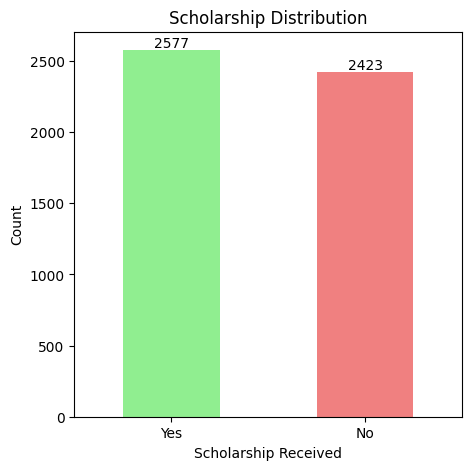

In [ ]:
# Visualize the distribution of the 'Scholarship Received' variable

print(df.value_counts('scholarship_received'))
plt.figure(figsize=(5, 5))
ax = df['scholarship_received'].value_counts().plot(
    kind='bar',
    color=['lightgreen', 'lightcoral']
)
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title('Scholarship Distribution')
plt.xlabel('Scholarship Received')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

visa_status
F1                       808
J1                       848
Schengen Student Visa    863
Student Visa             817
Study Permit             811
Tier 4                   853
Name: count, dtype: int64


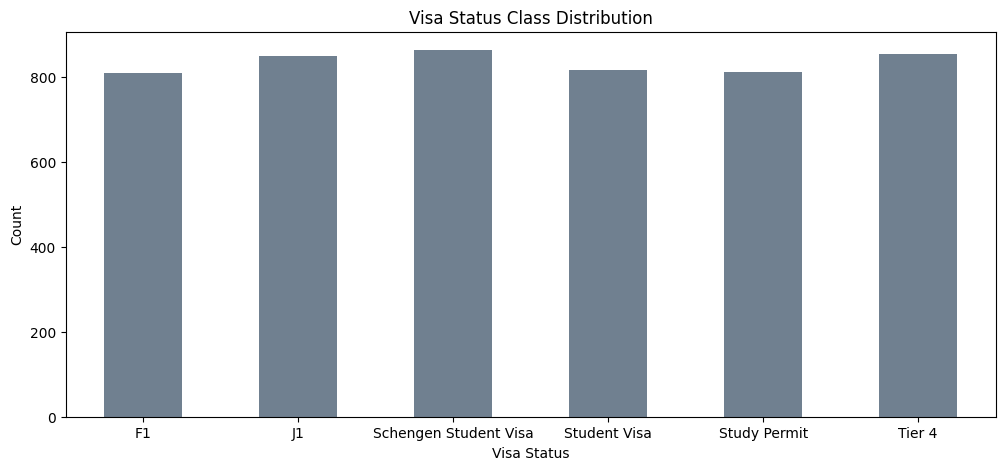

In [ ]:
# Visualize the distribution of 'Visa Status' variable
print(df.value_counts('visa_status').sort_index())

plt.figure(figsize=(12, 5))
df['visa_status'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Visa Status Class Distribution')
plt.xlabel('Visa Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

placement_status
Placed        2509
Not Placed    2491
Name: count, dtype: int64


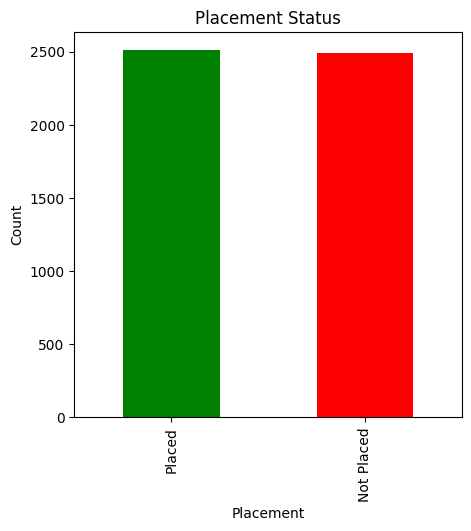

In [ ]:
# Visualize the distribution of 'Placement Status' variable
print(df.value_counts('placement_status'))

plt.figure(figsize=(5, 5))
df['placement_status'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Placement Status')
plt.xlabel('Placement')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

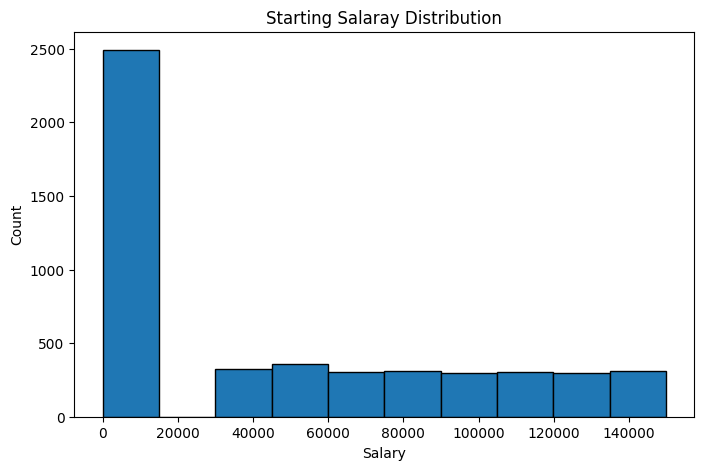

In [ ]:
# Visualize the distribution of 'Starting Salaray Distribution' variable
plt.figure(figsize=(8, 5))
plt.hist(df['starting_salary_usd'].dropna(), edgecolor='black')
# dropna eliminates the null/missing values but not in df
plt.title('Starting Salaray Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.show()

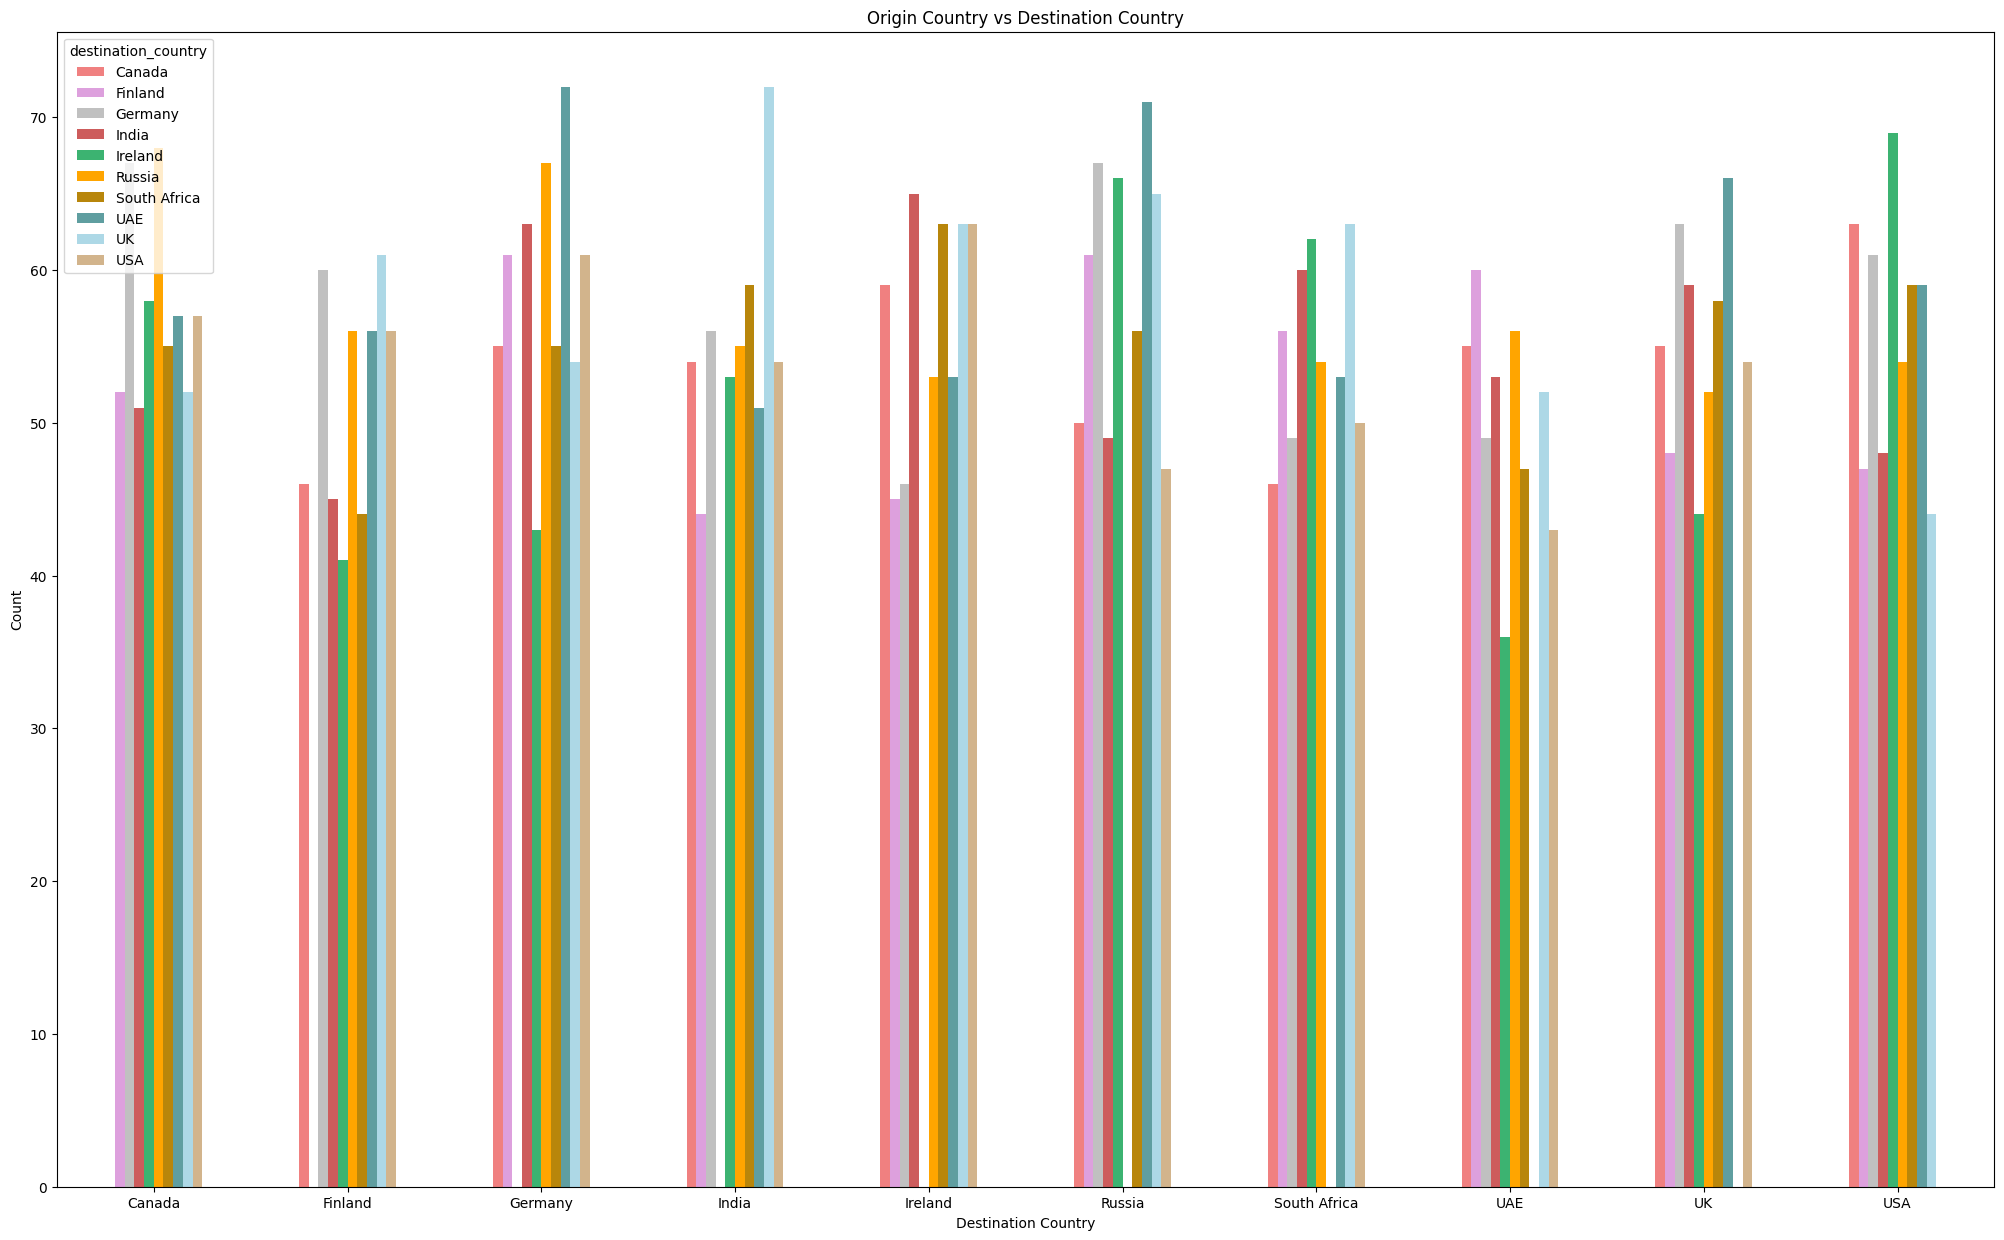

In [ ]:
# Visualize the relationship between 'Origin Country' and 'Destination Country'

pd.crosstab(df['origin_country'], df['destination_country']) \
    .plot(kind='bar', figsize=(25, 15), color=['lightcoral', 'plum', 'silver', 'indianred', 'mediumseagreen', 'orange', 'darkgoldenrod', 'cadetblue', 'lightblue', 'tan'])

plt.title('Origin Country vs Destination Country')
plt.xlabel('Destination Country')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

                     year_of_enrollment  graduation_year  starting_salary_usd  \
year_of_enrollment             1.000000         0.868798             0.005694   
graduation_year                0.868798         1.000000             0.010985   
starting_salary_usd            0.005694         0.010985             1.000000   
gpa_or_score                  -0.015113        -0.024771            -0.027943   
test_score                    -0.007475        -0.014613             0.013177   

                     gpa_or_score  test_score  
year_of_enrollment      -0.015113   -0.007475  
graduation_year         -0.024771   -0.014613  
starting_salary_usd     -0.027943    0.013177  
gpa_or_score             1.000000   -0.002226  
test_score              -0.002226    1.000000  


<Figure size 800x600 with 0 Axes>

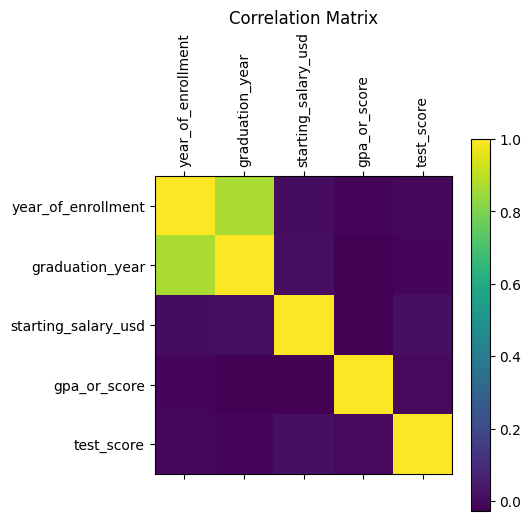

In [ ]:
# Correlation matrix plot before preprocessing
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

# Data Preprocessing

In [ ]:
# Drop Redundant Features/Columns
df = df.drop(['student_id', 'destination_city', 'university_name', 'course_name','post_graduation_visa', 'placement_country', 'placement_company'], axis=1) #axis=1 is column, 0 is row
df

,origin_country,destination_country,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,starting_salary_usd,gpa_or_score,visa_status,language_proficiency_test,test_score
0,Finland,Russia,Engineering,2021,No,Higher Ranking,2024,Placed,36416,3.92,Tier 4,TOEFL,7.8
1,UK,Germany,Law,2023,Yes,Job Opportunities,2024,Placed,32956,2.60,Study Permit,PTE,7.9
2,Ireland,Canada,Arts,2019,No,Scholarship,2020,Not Placed,0,2.72,F1,NaN,0.0
3,UAE,UK,Social Sciences,2021,Yes,Quality of Life,2023,Placed,50892,3.71,Schengen Student Visa,NaN,0.0
4,South Africa,Germany,Law,2020,Yes,Political Stability,2021,Placed,54790,2.96,Schengen Student Visa,PTE,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Canada,Germany,Engineering,2023,No,Scholarship,2024,Placed,98568,3.96,Tier 4,Duolingo,6.9
4996,India,Ireland,Law,2023,Yes,Quality of Life,2026,Placed,32643,3.93,F1,TOEFL,7.5
4997,UK,India,Natural Sciences,2023,Yes,Scholarship,2026,Placed,100777,3.76,Study Permit,TOEFL,8.8
4998,Germany,Russia,Business,2020,Yes,Scholarship,2022,Not Placed,0,3.72,Schengen Student Visa,IELTS,8.6


In [ ]:
# Check for missing values
df.isnull().sum()

,0
origin_country,0
destination_country,0
field_of_study,0
year_of_enrollment,0
scholarship_received,0
enrollment_reason,0
graduation_year,0
placement_status,0
starting_salary_usd,0
gpa_or_score,0


In [ ]:
# Converting Categorical Variables to Numerical

df['origin_country'] = df['origin_country'].astype('category').cat.codes
df['destination_country'] = df['destination_country'].astype('category').cat.codes

df['field_of_study'] = df['field_of_study'].astype('category').cat.codes
df['enrollment_reason'] = df['enrollment_reason'].astype('category').cat.codes

df['placement_status'] = df['placement_status'].astype('category').cat.codes
df['scholarship_received'] = df['scholarship_received'].astype('category').cat.codes

df['language_proficiency_test'] = df['language_proficiency_test'].astype('category').cat.codes
df['visa_status'] = df['visa_status'].astype('category').cat.codes

In [ ]:
df.head()

,origin_country,destination_country,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,starting_salary_usd,gpa_or_score,visa_status,language_proficiency_test,test_score
0,1,5,3,2021,0,0,2024,1,36416,3.92,5,3,7.8
1,8,2,4,2023,1,1,2024,1,32956,2.60,4,2,7.9
2,4,0,0,2019,0,4,2020,0,0,2.72,0,-1,0.0
3,7,8,7,2021,1,3,2023,1,50892,3.71,2,-1,0.0
4,6,2,4,2020,1,2,2021,1,54790,2.96,2,2,8.2


In [ ]:
# Check for unique values
df.nunique()

,0
origin_country,10
destination_country,10
field_of_study,8
year_of_enrollment,5
scholarship_received,2
enrollment_reason,5
graduation_year,7
placement_status,2
starting_salary_usd,2485
gpa_or_score,151


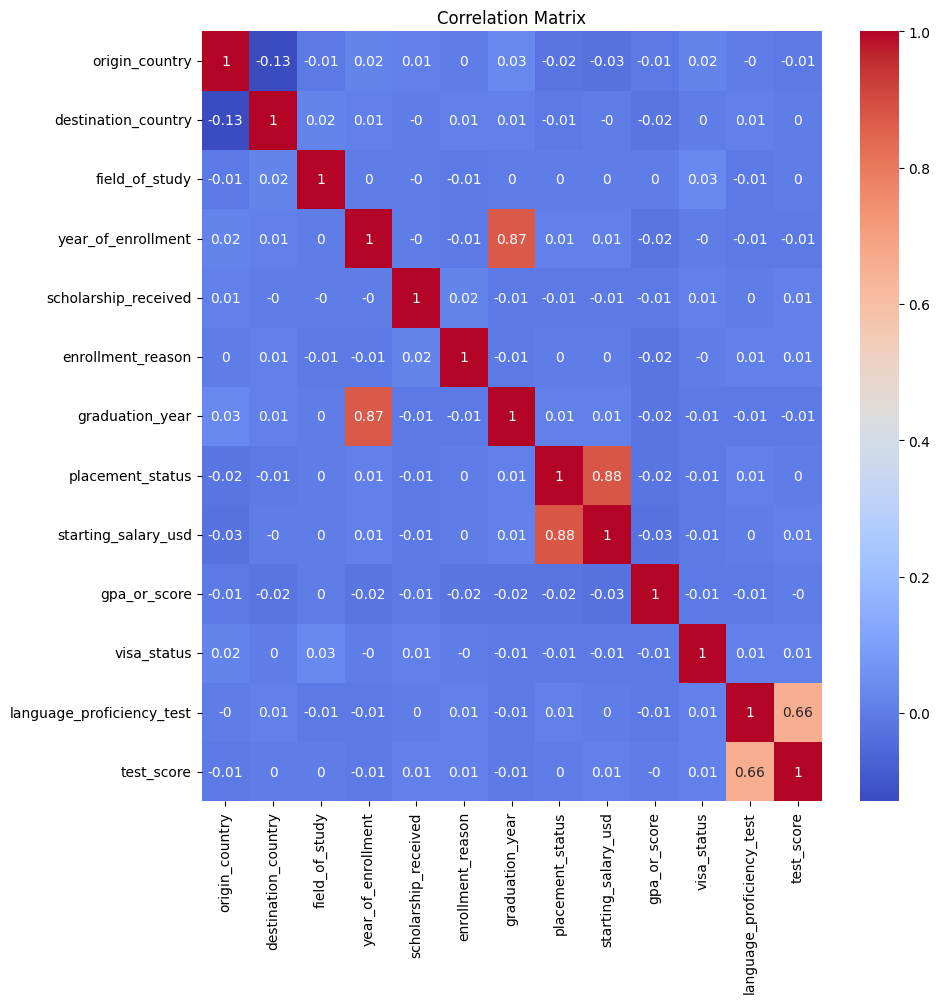

In [ ]:
plt.figure(figsize=(10, 10))
correlation_matrix = df.corr(numeric_only=True).round(2)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Implementing Machine Learnin Models Using Scikit-learn Library

In [ ]:
def visualize_feature_importance(feature_importance, model_name):

  plt.figure(figsize=(12, 8))

  sns.barplot(
      x='Importance',
      y='Feature',
      data=feature_importance,
      palette='viridis'
  )

  plt.title(f'Feature Importance - {model_name}')
  plt.xlabel('Importance Score')
  plt.ylabel('Features')

  plt.tight_layout()
  plt.show()

In [ ]:
# Split the data into 80-20 train-test split

X = df.drop(['scholarship_received'], axis=1) # features
y = df['scholarship_received'] # target column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# display the shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 12)
X_test shape: (1000, 12)
y_train shape: (4000,)
y_test shape: (1000,)


Decision Tree Classifier F1-score: 0.4985
Decision Tree Classifier Accuracy: 0.501


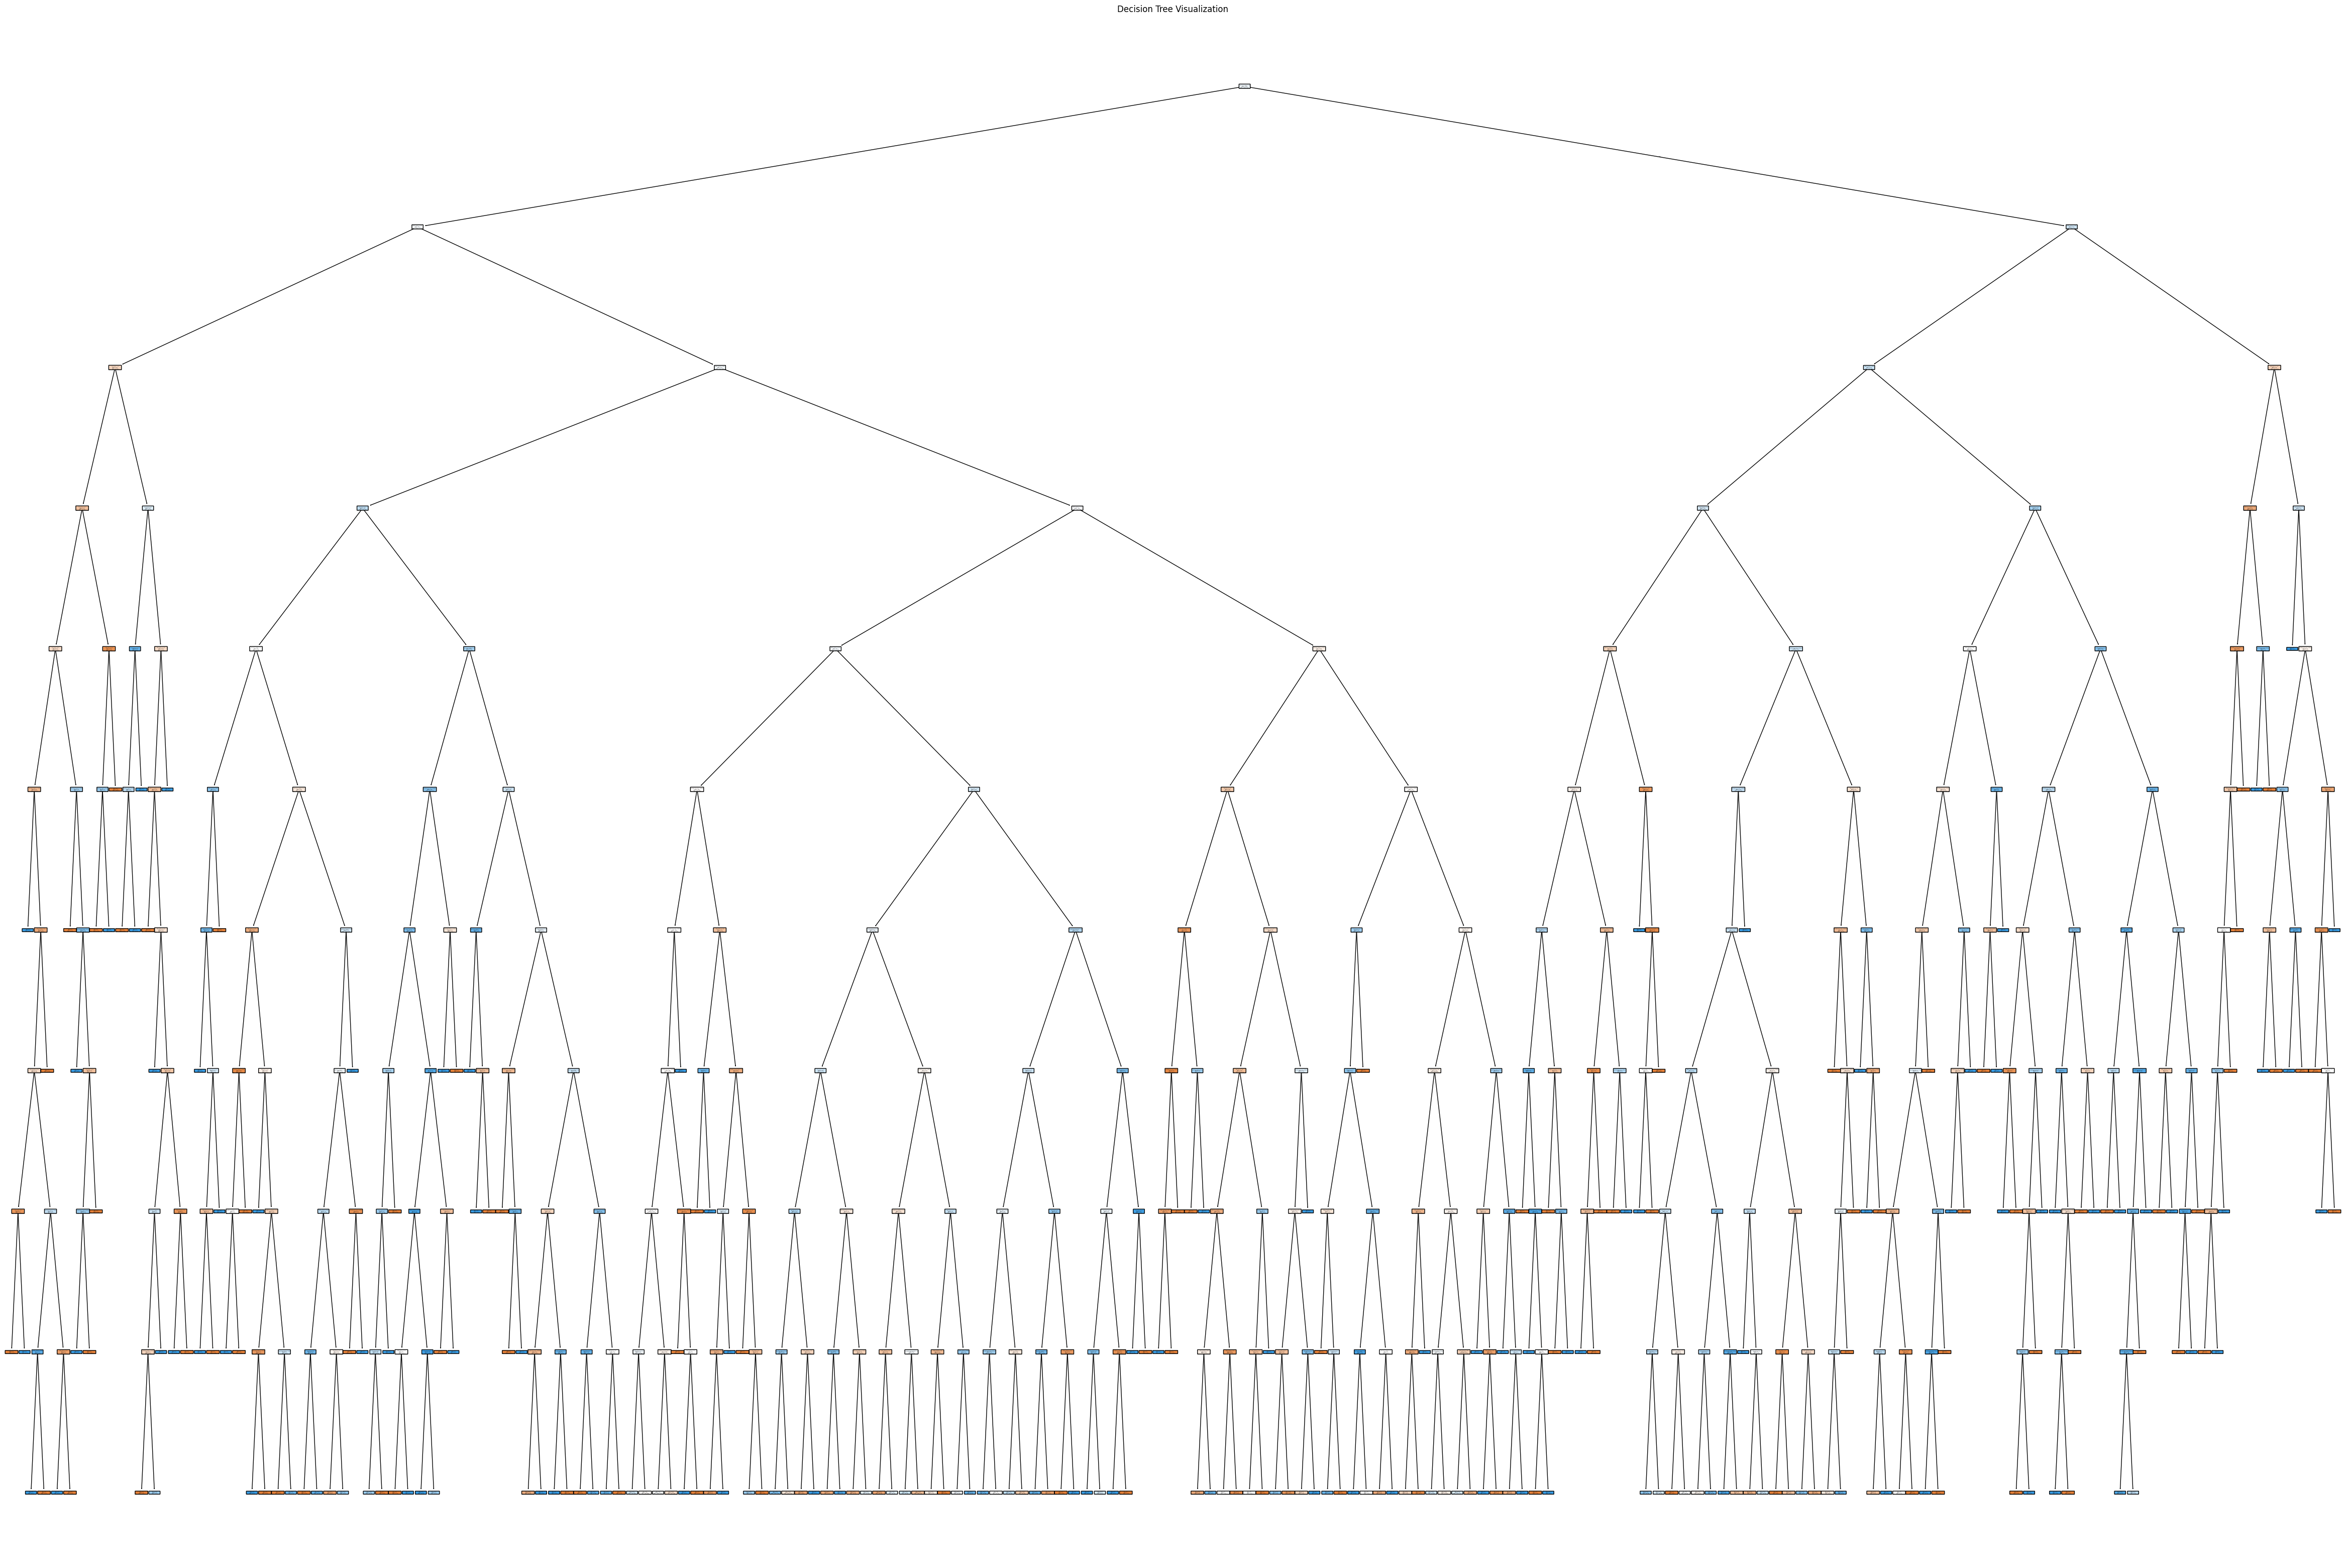

In [ ]:
# Implementing Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(criterion='gini', max_depth = 10, random_state=42)
decision_tree_model.fit(X_train, y_train)

# Predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)
# Evaluate the model
dt_f1 = f1_score(y_test, y_pred_dt,average='weighted')
print(f"Decision Tree Classifier F1-score: {dt_f1:.4f}")
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Classifier Accuracy:", dt_accuracy)
#accuracy = no.of correctly predicted data / total test data

# Visualize the Decision Tree
plt.figure(figsize=(60, 40))
plot_tree(decision_tree_model, feature_names=X.columns, class_names=['Scholarship not received', 'Scholarship received'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

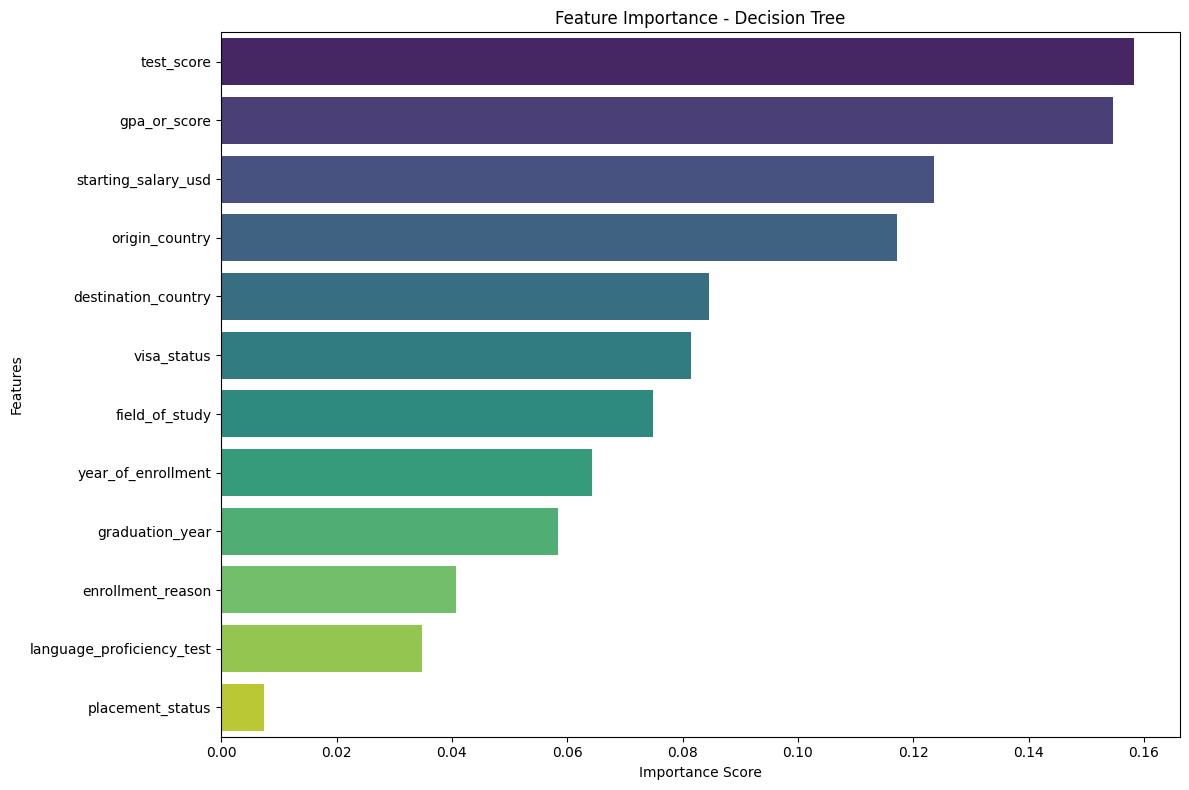

In [ ]:
# Get feature importance scores for Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': decision_tree_model.feature_importances_
})

# Sort by importance
feature_importance_dt = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

visualize_feature_importance(feature_importance_dt, "Decision Tree")

Random Forest Classifier F1-score: 0.4440
Random Forest Classifier Accuracy: 0.501


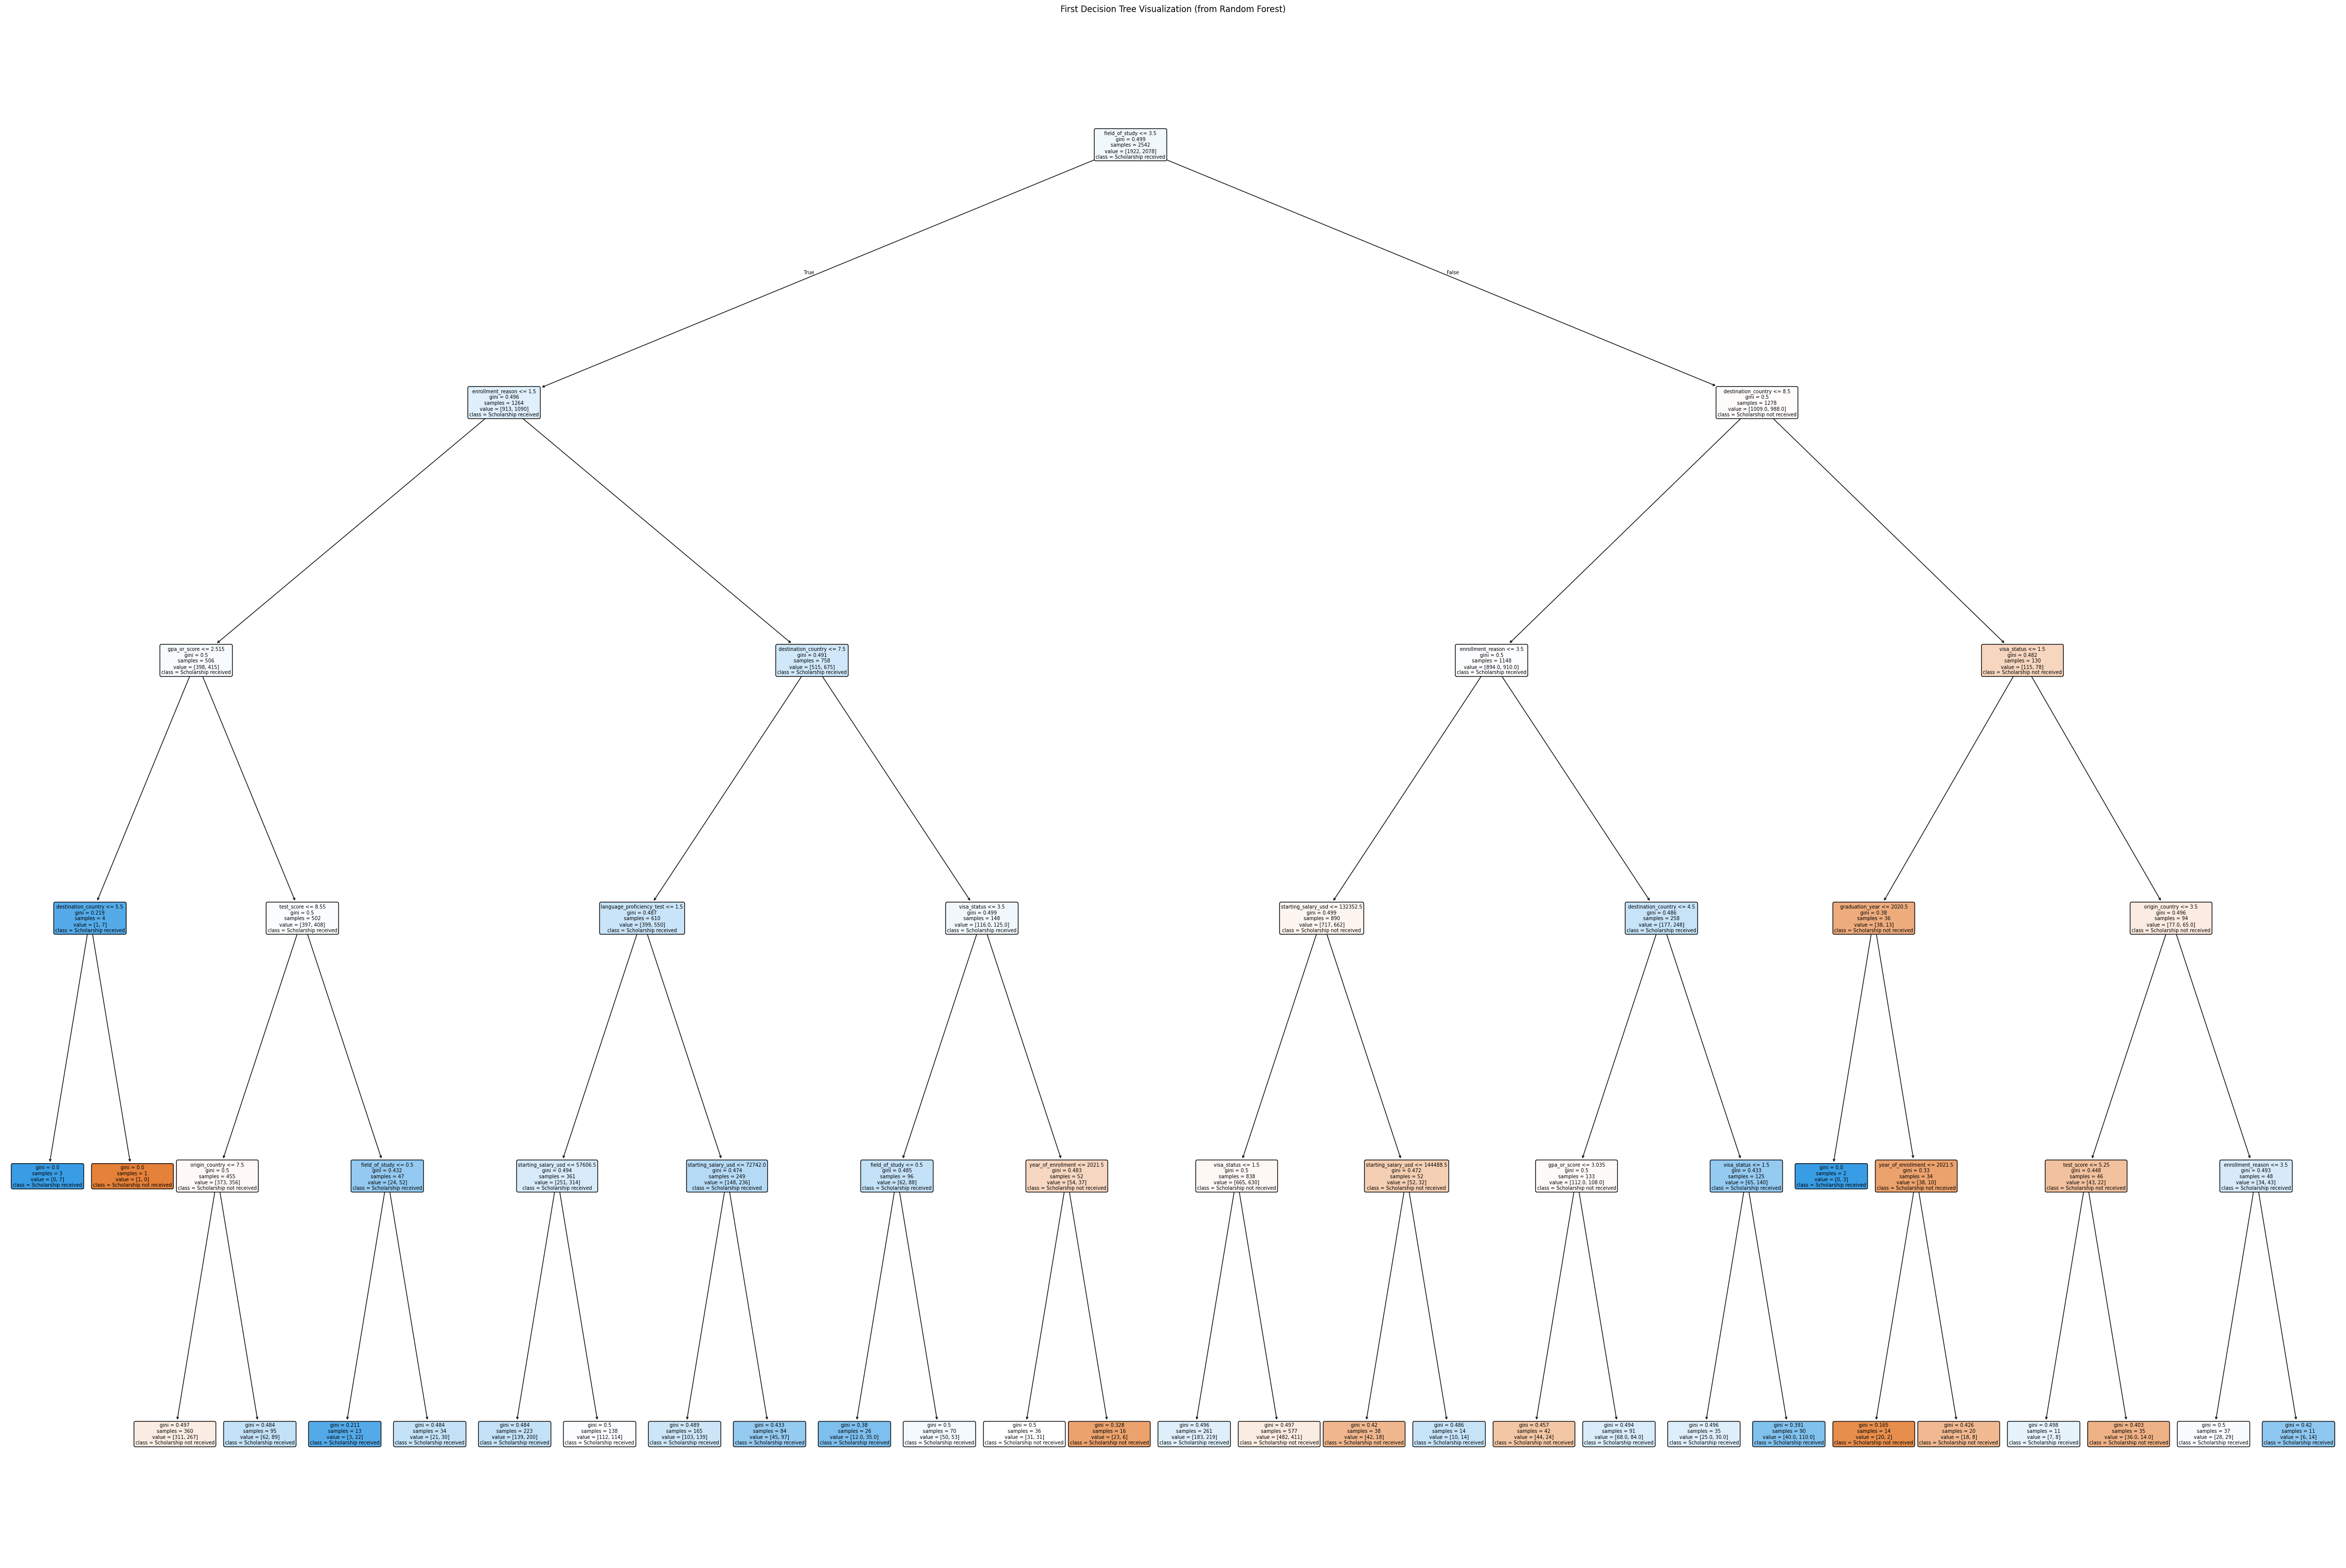

In [ ]:
# Implementing Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, max_depth = 5, criterion='gini', bootstrap=True, random_state=42)
random_forest_model.fit(X_train, y_train)

# Predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
rf_f1 = f1_score(y_test, y_pred_rf,average='weighted')
print(f"Random Forest Classifier F1-score: {rf_f1:.4f}")
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Classifier Accuracy:", rf_accuracy)

# Visualize one of the decision trees (first tree) in the Forest
plt.figure(figsize=(60, 40))
plot_tree(random_forest_model.estimators_[0], feature_names=X.columns, class_names=['Scholarship not received', 'Scholarship received'], filled=True, rounded=True)
plt.title('First Decision Tree Visualization (from Random Forest)')
plt.show()

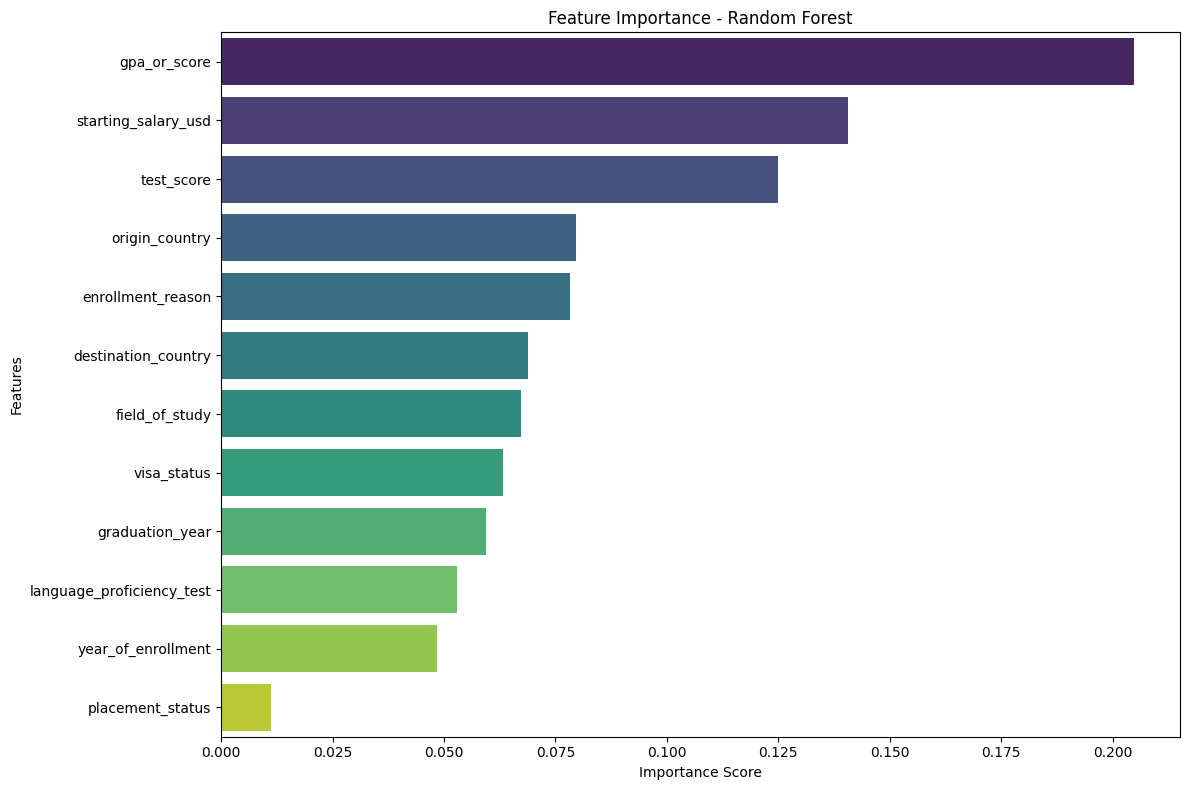

In [ ]:
# Get feature importance scores Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest_model.feature_importances_
})

# Sort by importance
feature_importance_rf = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

visualize_feature_importance(feature_importance_rf, "Random Forest")

In [ ]:
# Implementing K Nearest Neighbour
k = 5
knn = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
knn_f1 = f1_score(y_test, y_pred_knn,average='weighted')
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN F1-score: {knn_f1:.4f}")
print("KNN Accuracy:", knn_accuracy)

KNN F1-score: 0.5139
KNN Accuracy: 0.514


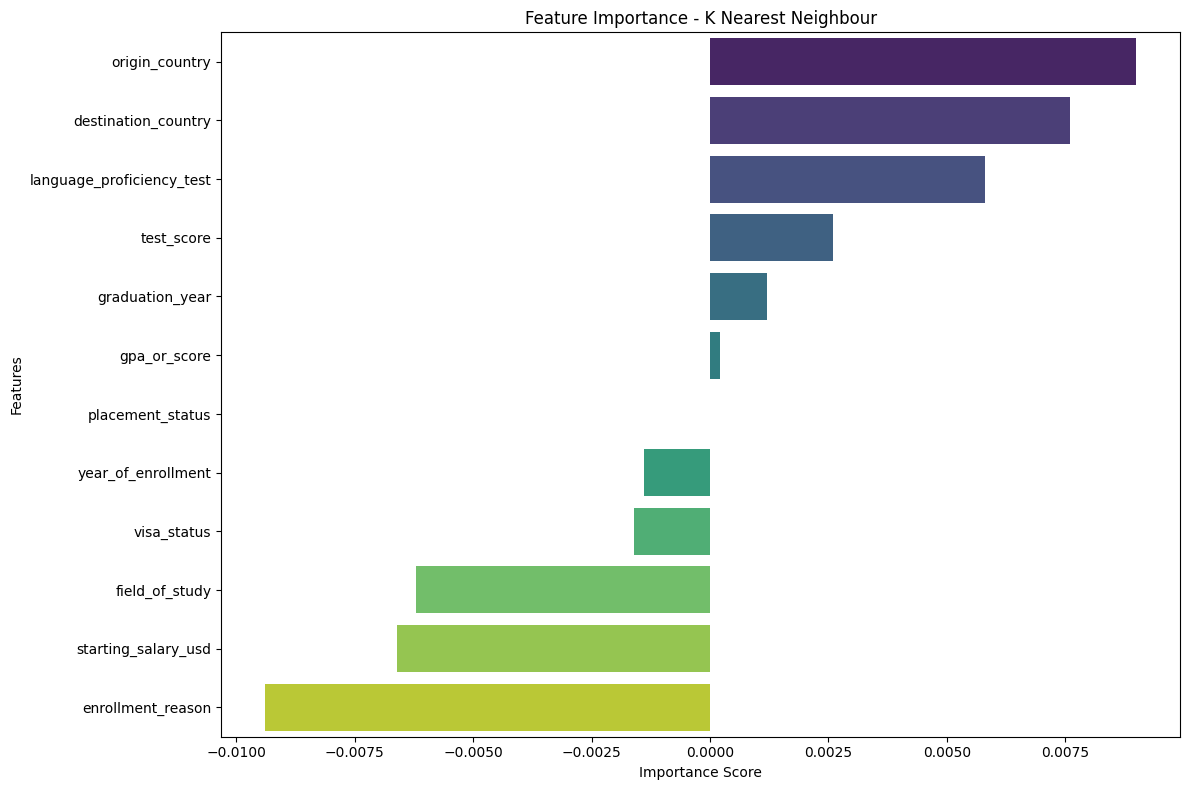

In [ ]:
# Get feature importance scores for K Nearest Neighbour
result = permutation_importance(
    knn,
    X_test,
    y_test,
    n_repeats = 5,
    random_state = 42
)

# Create dataframe
feature_importance_knn = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

# Sort by importance
feature_importance_knn = feature_importance_knn.sort_values(
    by='Importance',
    ascending=False
)

visualize_feature_importance(feature_importance_knn, "K Nearest Neighbour")

In [ ]:
# Implementing Logistic Regression
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(X_train, y_train)

y_pred_lr = logistic_regression.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr,average='weighted')

print(f"Logistic Regression F1-score: {lr_f1:.4f}")
print(f"Logistic Regression Accuracy: {round(lr_accuracy,2)}")

Logistic Regression F1-score: 0.4509
Logistic Regression Accuracy: 0.5


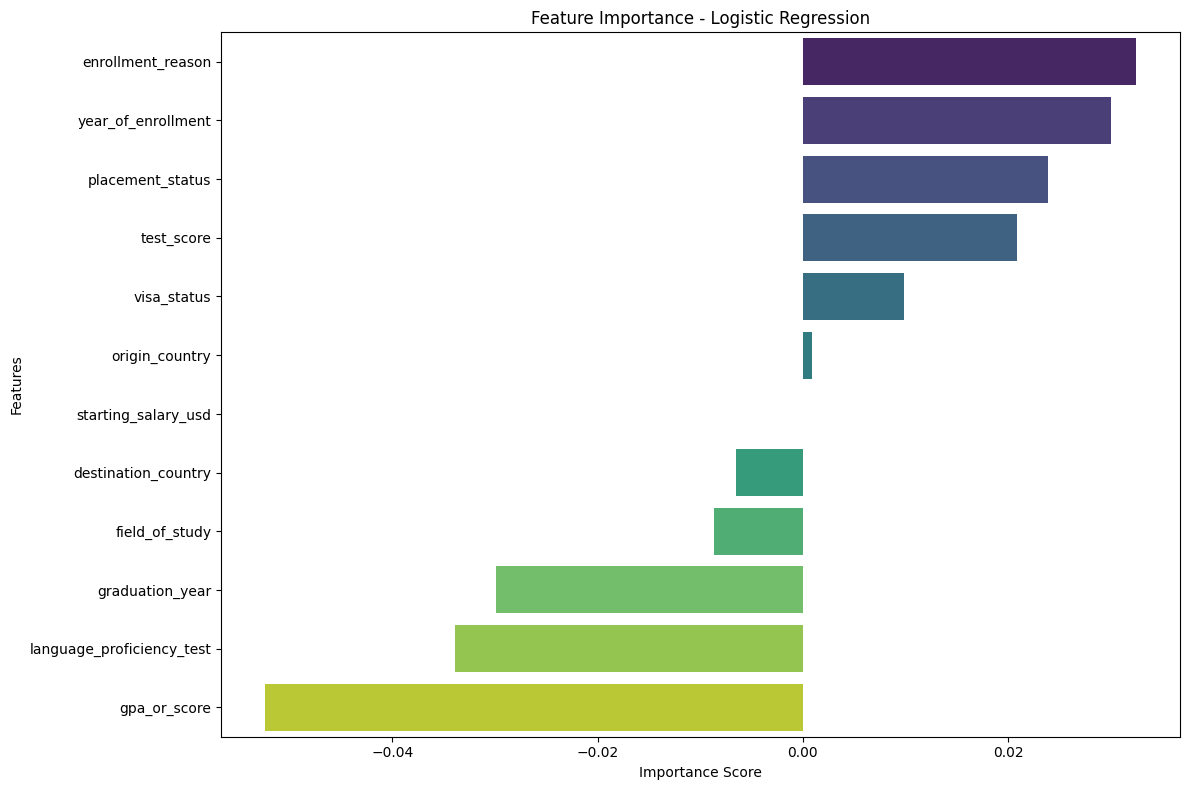

In [ ]:
# Get feature importance scores for Logistic Regression
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': logistic_regression.coef_[0]
})

# Sort by importance
feature_importance_lr = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

visualize_feature_importance(feature_importance_lr, "Logistic Regression")

In [ ]:
# Implementing Gaussian Naive Bayes
Gnaive_bayes = GaussianNB()
Gnaive_bayes.fit(X_train, y_train)

# Predict labels on the test set
y_pred_gnb = Gnaive_bayes.predict(X_test)
gnb_f1 = f1_score(y_test, y_pred_gnb,average='weighted')
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)

print(f"Gaussian Naive Bayes F1-score: {gnb_f1:.4f}")
print("Gaussian Naive Bayes Accuracy:", gnb_accuracy)

Gaussian Naive Bayes F1-score: 0.3856
Gaussian Naive Bayes Accuracy: 0.489


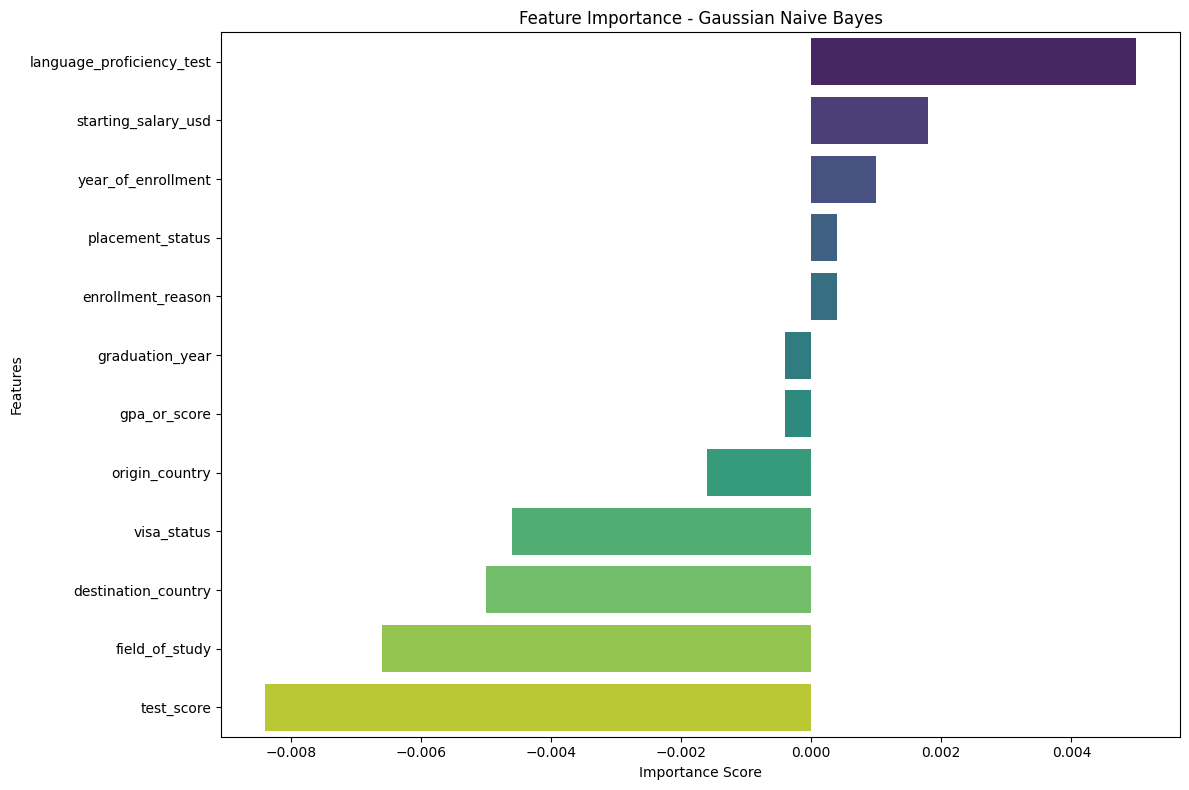

In [ ]:
# Get feature importance scores for Gaussian Naive Bayes
result = permutation_importance(
    Gnaive_bayes,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

# Create dataframe
feature_importance_gnb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

# Sort by importance
feature_importance_gnb = feature_importance_gnb.sort_values(
    by='Importance',
    ascending=False
)

visualize_feature_importance(feature_importance_gnb, "Gaussian Naive Bayes")

# **Result Analysis**

In [ ]:
results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression', 'Gaussian Naive Bayes'],
    'Accuracy': [knn_accuracy, dt_accuracy, rf_accuracy, lr_accuracy, gnb_accuracy],
    'F1 Score': [knn_f1,dt_f1,rf_f1,lr_f1,gnb_f1]})

print(results)

                  Model  Accuracy  F1 Score
0                   KNN     0.514  0.513860
1         Decision Tree     0.501  0.498543
2         Random Forest     0.501  0.444033
3   Logistic Regression     0.501  0.450889
4  Gaussian Naive Bayes     0.489  0.385642


In [ ]:
models = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "Gaussian Naive Bayes": y_pred_gnb
}

In [ ]:
# Function to display confusion matrix and calculate TPR/FPR
def evaluate_model(y_true, y_pred, model_name):

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Binary classification case
    if cm.shape == (2,2):
        TN, FP, FN, TP = cm.ravel()

        # True Positive Rate
        TPR = TP / (TP + FN)

        # False Positive Rate
        FPR = FP / (FP + TN)

        print(f"{model_name} True Positive Rate (TPR): {TPR:.4f}")
        print(f"{model_name} False Positive Rate (FPR): {FPR:.4f}")
    else:
        print("TPR and FPR shown only for binary classification.")



Decision Tree Confusion Matrix:
[[215 284]
 [215 286]]


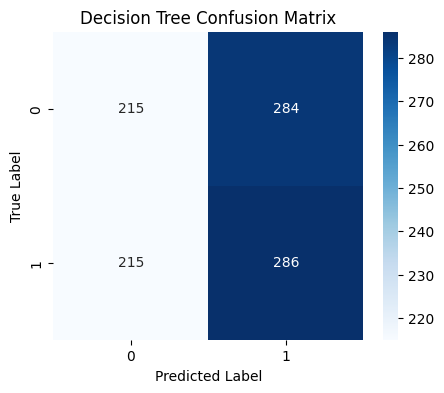

Decision Tree True Positive Rate (TPR): 0.5709
Decision Tree False Positive Rate (FPR): 0.5691

Random Forest Confusion Matrix:
[[ 90 409]
 [ 90 411]]


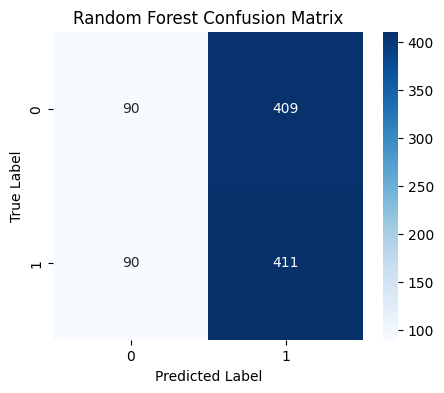

Random Forest True Positive Rate (TPR): 0.8204
Random Forest False Positive Rate (FPR): 0.8196

KNN Confusion Matrix:
[[248 251]
 [235 266]]


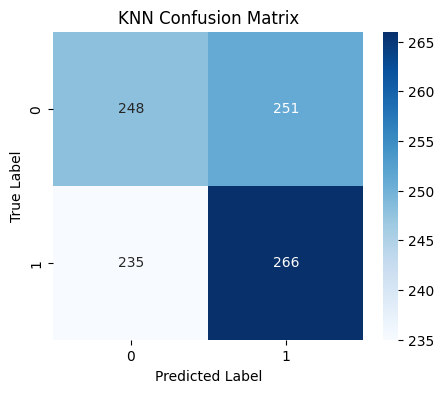

KNN True Positive Rate (TPR): 0.5309
KNN False Positive Rate (FPR): 0.5030

Logistic Regression Confusion Matrix:
[[ 99 400]
 [ 99 402]]


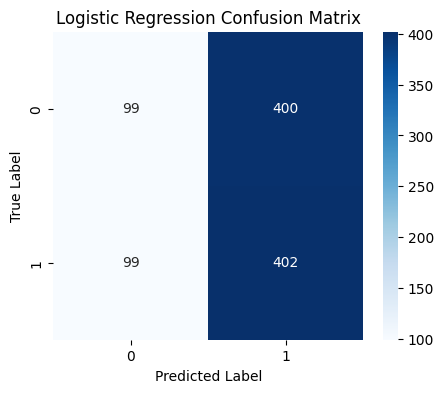

Logistic Regression True Positive Rate (TPR): 0.8024
Logistic Regression False Positive Rate (FPR): 0.8016

GNB Confusion Matrix:
[[ 39 460]
 [ 51 450]]


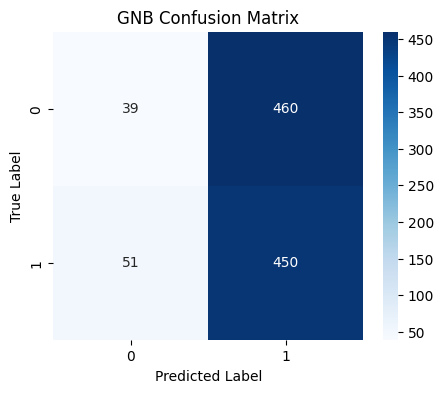

GNB True Positive Rate (TPR): 0.8982
GNB False Positive Rate (FPR): 0.9218


In [ ]:
# ---------------- Decision Tree ----------------
evaluate_model(y_test, y_pred_dt, "Decision Tree")

# ---------------- Random Forest ----------------
evaluate_model(y_test, y_pred_rf, "Random Forest")

# ---------------- KNN ----------------
evaluate_model(y_test, y_pred_knn, "KNN")

# ---------------- Logistic Regression ----------------
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# ---------------- GaussianNB ----------------
evaluate_model(y_test, y_pred_gnb, "GNB")

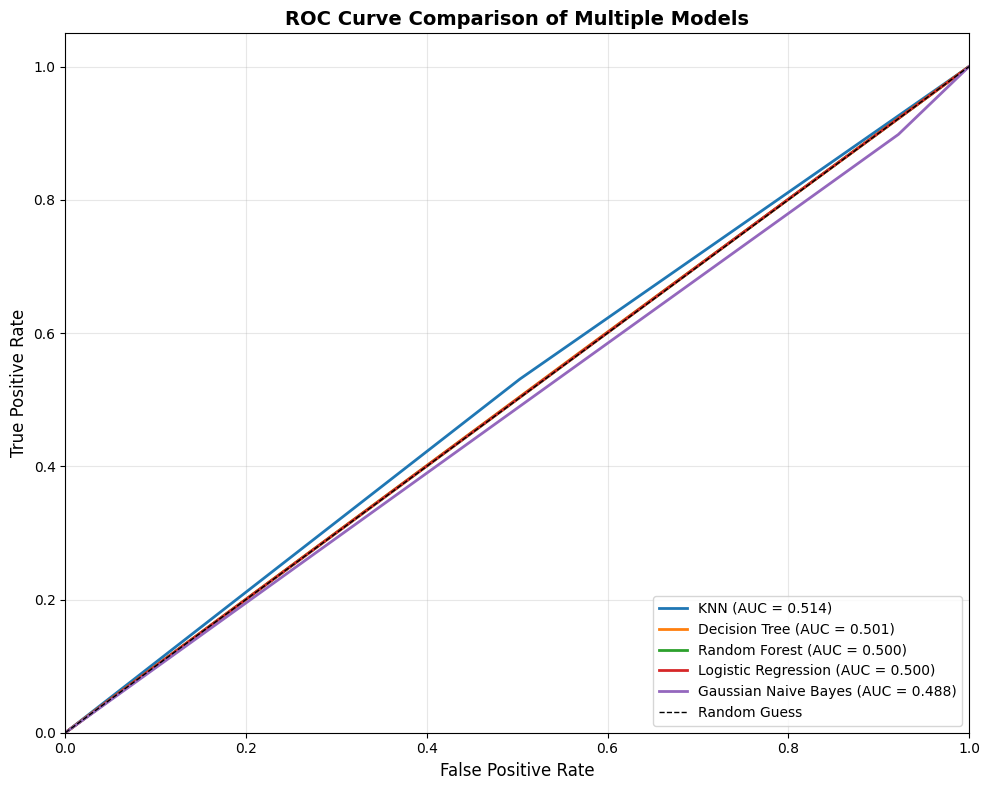

In [ ]:
# True labels (binarized)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

plt.figure(figsize=(10, 8))

for name, y_pred in models.items():
    # Binarize predicted labels
    y_pred_bin = label_binarize(y_pred, classes=classes)

    # Compute micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_bin.ravel())
    roc_auc = auc(fpr, tpr)

    # Plot one ROC curve per model
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison of Multiple Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()